#IPL Data Analysis 
### Aalaysis of Indian Premier League match data

This project explores pattern in IPL matches such as team performance, toss impact, and winning trends

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="darkgrid")

In [2]:
matches = pd.read_csv('../data/matches.csv')

In [3]:
matches.info()

<class 'pandas.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   str    
 2   city             1044 non-null   str    
 3   date             1095 non-null   str    
 4   match_type       1095 non-null   str    
 5   player_of_match  1090 non-null   str    
 6   venue            1095 non-null   str    
 7   team1            1095 non-null   str    
 8   team2            1095 non-null   str    
 9   toss_winner      1095 non-null   str    
 10  toss_decision    1095 non-null   str    
 11  winner           1090 non-null   str    
 12  result           1095 non-null   str    
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   str    
 17  method           21 non-n

In [4]:
matches.describe()

,id,result_margin,target_runs,target_overs
count,1.095000e+03,1076.000000,1092.000000,1092.000000
mean,9.048283e+05,17.259294,165.684066,19.759341
std,3.677402e+05,21.787444,33.427048,1.581108
min,3.359820e+05,1.000000,43.000000,5.000000
25%,5.483315e+05,6.000000,146.000000,20.000000
50%,9.809610e+05,8.000000,166.000000,20.000000
75%,1.254062e+06,20.000000,187.000000,20.000000
max,1.426312e+06,146.000000,288.000000,20.000000


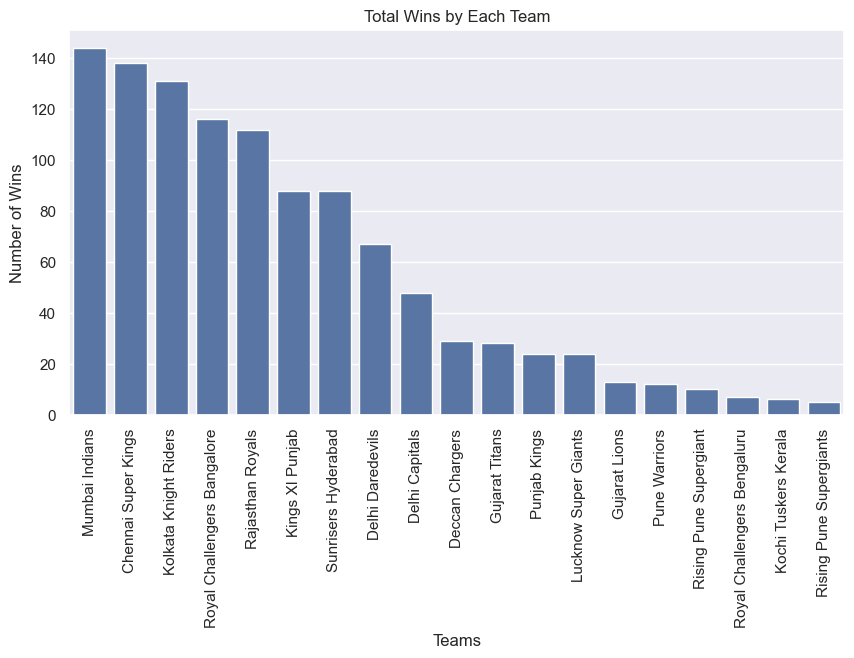

In [5]:
wins = matches['winner'].value_counts()

plt.figure(figsize=(10,5))
sns.barplot(x=wins.index, y=wins.values)
plt.xticks(rotation=90)
plt.title("Total Wins by Each Team")
plt.xlabel("Teams")
plt.ylabel("Number of Wins")
plt.show()

## Insight 1: Team Performance

- Teams like Mumbai Indians and Chennai Super Kings have the highest number of wins.
- This indicates consistent performance across seasons.


In [6]:
matches.columns

Index(['id', 'season', 'city', 'date', 'match_type', 'player_of_match',
       'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner',
       'result', 'result_margin', 'target_runs', 'target_overs', 'super_over',
       'method', 'umpire1', 'umpire2'],
      dtype='str')

In [7]:
matches['toss_analysis'] = matches['toss_winner'] == matches['winner']

In [8]:
matches[['toss_winner', 'winner', 'toss_analysis']].head(10)

,toss_winner,winner,toss_analysis
0,Royal Challengers Bangalore,Kolkata Knight Riders,False
1,Chennai Super Kings,Chennai Super Kings,True
2,Rajasthan Royals,Delhi Daredevils,False
3,Mumbai Indians,Royal Challengers Bangalore,False
4,Deccan Chargers,Kolkata Knight Riders,False
5,Kings XI Punjab,Rajasthan Royals,False
6,Deccan Chargers,Delhi Daredevils,False
7,Mumbai Indians,Chennai Super Kings,False
8,Rajasthan Royals,Rajasthan Royals,True
9,Mumbai Indians,Kings XI Punjab,False


In [9]:
toss_counts= matches['toss_analysis'].value_counts()

In [10]:
print(toss_counts)

toss_analysis
True     554
False    541
Name: count, dtype: int64


In [11]:
total = toss_counts.sum()
percentage= (toss_counts[True]/total)*100
print(f"Toss winner won the match: {percentage:.2f}%")

Toss winner won the match: 50.59%


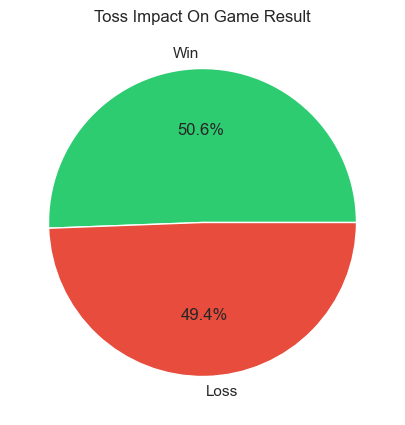

In [12]:
plt.figure(figsize=(10,5))
plt.pie(toss_counts, labels=['Win','Loss'],autopct='%1.1f%%',colors=['#2ecc71','#e74c3c'] )
plt.title('Toss Impact On Game Result')
plt.show()


## 🎯 Toss Impact Analysis
> Does winning the toss give a team an advantage in IPL?

Out of **1095 matches** analyzed, teams that won the toss went on to win the match 
only **50.6%** of the time — barely better than a coin flip. The remaining **49.4%** 
of toss winners still ended up losing the match.

**💡 Insight:** Winning the toss provides no significant advantage in IPL. 
The result is almost entirely decided by performance on the field, not the toss.

## 🏏 Toss Decision Analysis
> When teams win the toss, do they prefer to bat or field? And does that decision impact the result?

We analyze the `toss_decision` column to understand:
- What do teams **prefer** to do after winning the toss?
- Which decision — batting or fielding first — leads to more wins?

In [13]:
toss_decision_counts = matches['toss_decision'].value_counts()
print(toss_decision_counts)

toss_decision
field    704
bat      391
Name: count, dtype: int64


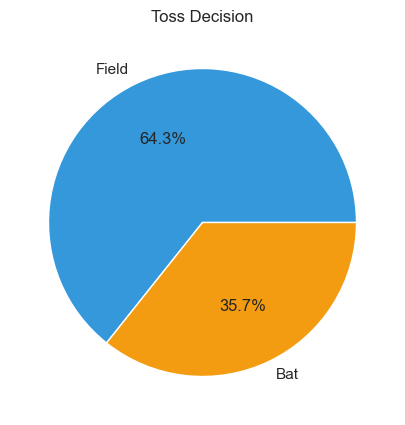

In [14]:
plt.figure(figsize=(10,5))
plt.pie(toss_decision_counts, 
        labels= ['Field','Bat'] #toss_decision_counts.index
        ,autopct='%1.1f%%', colors=['#3498db','#f39c12'])
plt.title('Toss Decision')
plt.show()

## 💡 Insight — Toss Decision Analysis

Out of **1095 matches**, teams winning the toss chose to **field first 704 times (64.3%)** 
compared to only **batting first 391 times (35.7%)**.

**Why?** Most IPL matches are played in the evening under lights. As the game 
progresses, **dew settles on the pitch** making the ball wet and harder to grip 
for bowlers — giving a clear advantage to the team batting second.

**💡 Key Takeaway:** In IPL, winning the toss almost always means choosing to 
field first — a strategic decision driven by dew conditions rather than coincidence.

## 📈 Season Trends Analysis
> How has IPL evolved over the years in terms of matches played?

We analyze the `season` column to understand:
- How many matches were played each season?
- Has IPL grown in size over the years?

In [15]:
season_matches = matches['season'].value_counts().sort_index()
print(season_matches)

season
2007/08    58
2009       57
2009/10    60
2011       73
2012       74
2013       76
2014       60
2015       59
2016       60
2017       59
2018       60
2019       60
2020/21    60
2021       60
2022       74
2023       74
2024       71
Name: count, dtype: int64


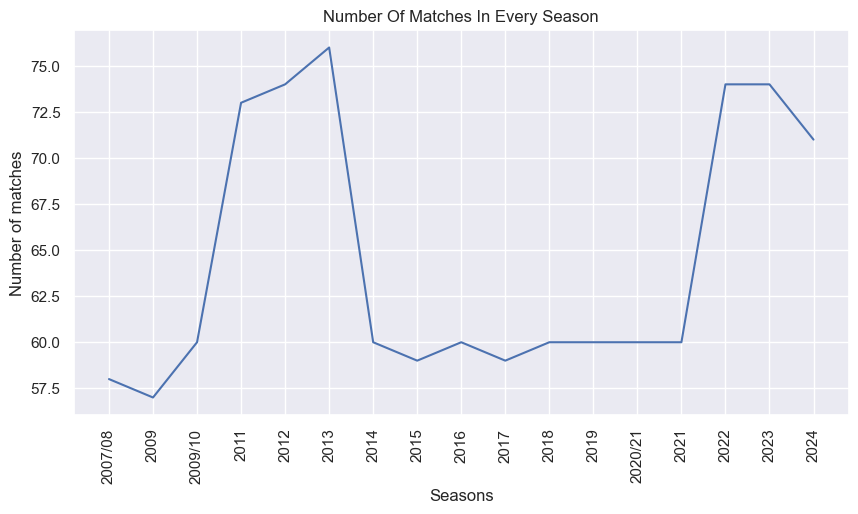

In [16]:
plt.figure(figsize=(10,5))
sns.lineplot(x=season_matches.index, y=season_matches.values)
plt.xticks(rotation=90)
plt.title('Number Of Matches In Every Season')
plt.xlabel('Seasons')
plt.ylabel('Number of matches')
plt.show()

## 💡 Insight — Season Trends Analysis

IPL has seen **17 seasons** from **2007 to 2024** with the number of matches 
varying across seasons.

- 📈 **2013** saw the highest number of matches — **76** in a single season
- 📉 Matches stabilized at around **60 per season** for several years (2014–2021)
- 🚀 **2022 onwards**, matches jumped back to **74** due to the addition of 
two new teams — **Lucknow Super Giants** and **Gujarat Titans**

**💡 Key Takeaway:** IPL has grown steadily over the years. The spike in 2022 
reflects the league's expansion, making it one of the biggest T20 leagues in the world.

## 🏟️ Venue Analysis
> Which venues have hosted the most IPL matches?

We analyze the `venue` column to understand:
- Which grounds have hosted the most matches?
- Which venues are the most popular in IPL history?

In [17]:
venue_counts = matches['venue']. value_counts()
print(venue_counts)
top_venues = venue_counts.head(10)


venue
Eden Gardens                                                             77
Wankhede Stadium                                                         73
M Chinnaswamy Stadium                                                    65
Feroz Shah Kotla                                                         60
Rajiv Gandhi International Stadium, Uppal                                49
MA Chidambaram Stadium, Chepauk                                          48
Sawai Mansingh Stadium                                                   47
Dubai International Cricket Stadium                                      46
Wankhede Stadium, Mumbai                                                 45
Punjab Cricket Association Stadium, Mohali                               35
Sheikh Zayed Stadium                                                     29
Sharjah Cricket Stadium                                                  28
MA Chidambaram Stadium, Chepauk, Chennai                                 28
Narend

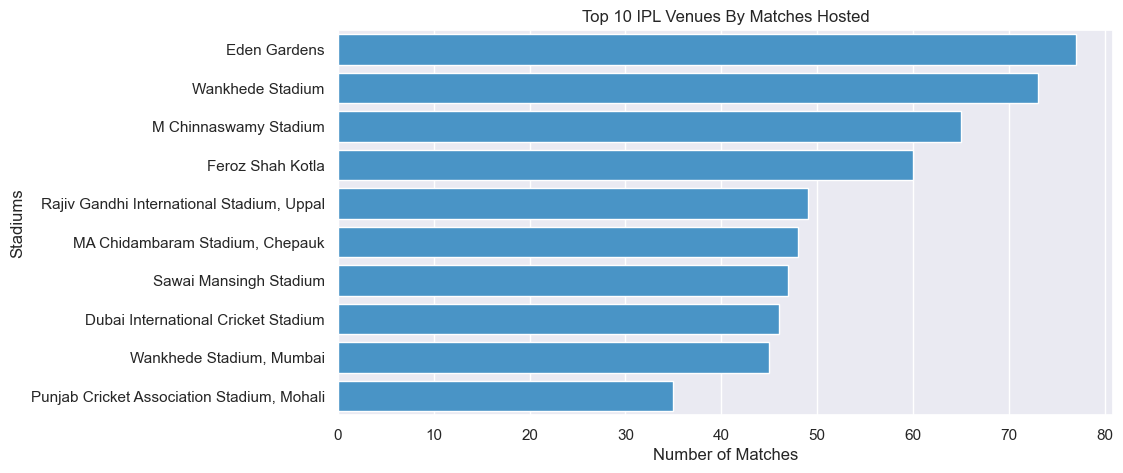

In [18]:
top_venues = venue_counts.head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_venues.values, y=top_venues.index, color='#3498db')
plt.title('Top 10 IPL Venues By Matches Hosted')
plt.xlabel('Number of Matches')
plt.ylabel('Stadiums')
plt.show()


## 💡 Insight — Venue Analysis

Analyzing the top 10 venues across **17 IPL seasons**, Eden Gardens comes out 
on top as the most used IPL venue.

- 🏟️ **Eden Gardens, Kolkata** — hosted the most matches (**77**), home of KKR
- 🏟️ **Wankhede Stadium, Mumbai** — close second (**73** matches), home of MI
- 🏟️ **M Chinnaswamy Stadium, Bengaluru** — third most used (**65** matches)

**💡 Key Takeaway:** Most frequently used venues are home grounds of 
traditionally strong IPL franchises — reflecting both their loyal fan base 
and world-class stadium infrastructure.

## 🏆 Top Players Analysis
> Which players have dominated IPL by winning the most Player of the Match awards?

We analyze the `player_of_match` column to understand:
- Which players have been the most impactful in IPL history?
- Who are the consistent match winners across all seasons?

In [19]:
top_players = matches['player_of_match']. value_counts()
print(top_players)

player_of_match
AB de Villiers     25
CH Gayle           22
RG Sharma          19
DA Warner          18
V Kohli            18
                   ..
R Sai Kishore       1
J Fraser-McGurk     1
WG Jacks            1
Simarjeet Singh     1
Shahbaz Ahmed       1
Name: count, Length: 291, dtype: int64


In [20]:
top_10_players = top_players.head(10)
print(top_10_players)

player_of_match
AB de Villiers    25
CH Gayle          22
RG Sharma         19
DA Warner         18
V Kohli           18
MS Dhoni          17
SR Watson         16
YK Pathan         16
RA Jadeja         16
SP Narine         15
Name: count, dtype: int64


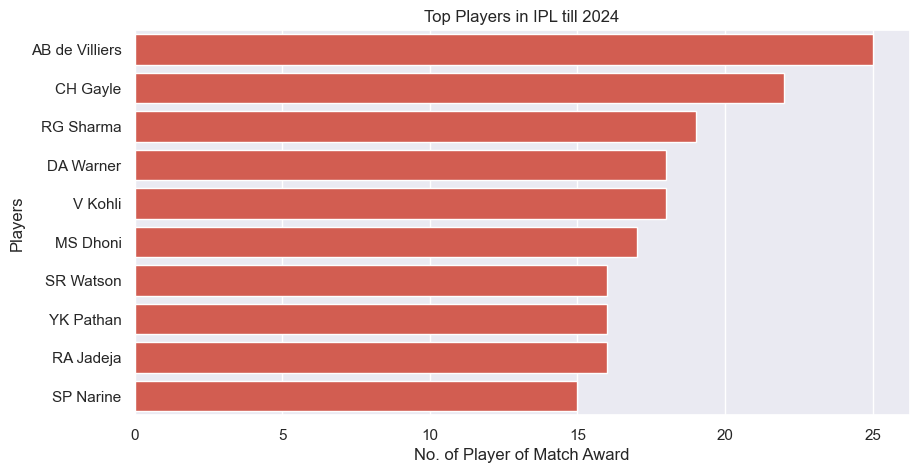

In [21]:
plt.figure(figsize=(10,5))
sns.barplot(x=top_10_players.values, y=top_10_players.index, color='#e74c3c')
plt.title('Top Players in IPL till 2024')
plt.xlabel('No. of Player of Match Award')
plt.ylabel('Players')
plt.show()

## 💡 Insight — Top Players Analysis

Analyzing **Player of the Match** awards across all IPL seasons reveals 
the most dominant individual performers in IPL history.

- 🏆 **AB de Villiers** — Most Player of the Match awards, truly the 
most impactful IPL batter of all time
- 🔥 **CH Gayle** — Close second, known for his explosive batting 
and record-breaking performances
- 💪 **RG Sharma** — Third on the list, consistency at its finest 
as MI's captain and opener
- ⚡ **DA Warner** — Fourth, a true IPL legend and one of the most 
feared openers in T20 history
- 👑 **V Kohli** — Fifth, the run machine — consistent as always 
across all formats and tournaments

**💡 Key Takeaway:** The top 5 are all world-class batters — reflecting 
that in T20 cricket, match-winning performances are predominantly 
driven by batting brilliance.

## 🎯 Win by Runs vs Wickets Analysis
> How do teams win in IPL — by runs (batting first) or by wickets (chasing)?

We analyze the `result` column to understand:
- How many matches were won by runs vs won by wickets?
- Which method of winning is more common in IPL?

In [22]:
result_method_count= matches['result']. value_counts()
print(result_method_count)

result
wickets      578
runs         498
tie           14
no result      5
Name: count, dtype: int64


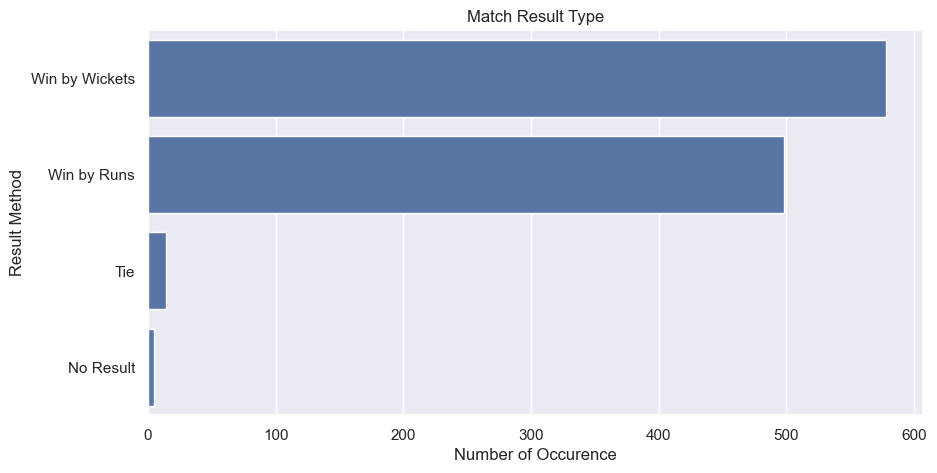

In [23]:
plt.figure(figsize=(10,5))
sns.barplot(x=result_method_count.values, y=['Win by Wickets','Win by Runs','Tie','No Result'])
plt.title('Match Result Type')
plt.xlabel('Number of Occurence')
plt.ylabel('Result Method')
plt.show()

## 💡 Insight — Win by Runs vs Wickets

Analyzing **1095 matches** across all IPL seasons reveals how teams win.

- 🏏 **Win by Wickets (578)** — Most common way to win, confirming 
that chasing is the preferred and more successful strategy in IPL
- 💥 **Win by Runs (498)** — Second most common, teams batting first 
can still dominate with a big score
- 🤝 **Ties (14)** — Rare but exciting! Decided by Super Over
- ❌ **No Result (5)** — Matches abandoned due to weather

**💡 Key Takeaway:** Chasing is king in IPL! This directly connects to 
our toss decision analysis — teams choose to field first because 
**winning by chasing is more common than defending a total.**

## ⚡ Super Over Analysis
> How often does a Super Over occur in IPL history?

We analyze the `super_over` column to understand:
- How many matches have gone to a Super Over?
- How rare is a Super Over in IPL?

In [24]:
superover_count= matches['super_over'].value_counts()
print(superover_count)

super_over
N    1081
Y      14
Name: count, dtype: int64


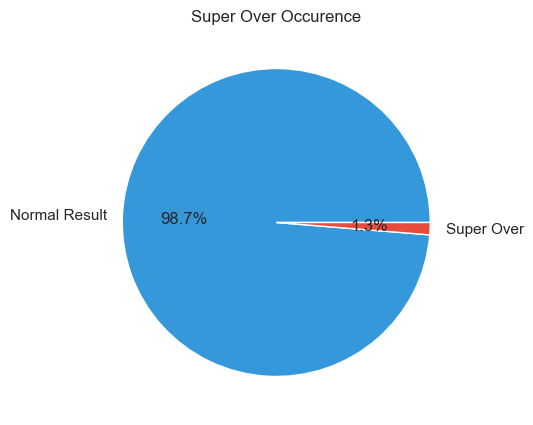

In [25]:
plt.figure(figsize=(10,5))
plt.pie(superover_count, labels=['Normal Result','Super Over'], autopct='%1.1f%%',colors=['#3498db','#e74c3c'])
plt.title('Super Over Occurence')
plt.show()

## 🧹 Data Cleaning & Quality Check
> Understanding the quality of our dataset before and after analysis.

We check for:
- Missing values
- Inconsistent entries
- Data quality issues

In [26]:
matches.isnull().sum()

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
toss_analysis         0
dtype: int64

In [27]:
matches['city'] = matches['city'].fillna('Unknown')

In [28]:
matches.isnull().sum()

id                    0
season                0
city                  0
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
toss_analysis         0
dtype: int64

In [29]:
matches['venue'].unique()

<StringArray>
[                                                'M Chinnaswamy Stadium',
                            'Punjab Cricket Association Stadium, Mohali',
                                                      'Feroz Shah Kotla',
                                                      'Wankhede Stadium',
                                                          'Eden Gardens',
                                                'Sawai Mansingh Stadium',
                             'Rajiv Gandhi International Stadium, Uppal',
                                       'MA Chidambaram Stadium, Chepauk',
                                            'Dr DY Patil Sports Academy',
                                                              'Newlands',
                                                      'St George's Park',
                                                             'Kingsmead',
                                                       'SuperSport Park',
                        

In [37]:
matches['venue']= matches['venue'].replace({
    'Eden Gardens, Kolkata':'Eden Gardens',
    'Wankhede Stadium, Mumbai':'Wankhede Stadium',
    'Punjab Cricket Association Stadium':'Punjab Cricket Association Stadium, Mohali',
    'Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh':'Punjab Cricket Association Stadium, Mohali',
    'Punjab Cricket Association IS Bindra Stadium, Mohali':'Punjab Cricket Association Stadium, Mohali',
    'Punjab Cricket Association IS Bindra Stadium':'Punjab Cricket Association Stadium, Mohali',
    'M.Chinnaswamy Stadium':'M Chinnaswamy Stadium',
    'M Chinnaswamy Stadium, Bengaluru':'M Chinnaswamy Stadium',
    'Himachal Pradesh Cricket Association Stadium, Dharamsala':'Himachal Pradesh Cricket Association Stadium',
    'Rajiv Gandhi International Stadium, Uppal':'Rajiv Gandhi International Stadium',
    'Rajiv Gandhi International Stadium, Uppal, Hyderabad':'Rajiv Gandhi International Stadium',
    'MA Chidambaram Stadium, Chepauk, Chennai':'MA Chidambaram Stadium, Chepauk',
    'MA Chidambaram Stadium': 'MA Chidambaram Stadium, Chepauk',
    'Arun Jaitley Stadium, Delhi': 'Arun Jaitley Stadium',
    'Feroz Shah Kotla': 'Arun Jaitley Stadium',
    'Dr DY Patil Sports Academy, Mumbai': 'Dr DY Patil Sports Academy',
    'Maharashtra Cricket Association Stadium, Pune': 'Maharashtra Cricket Association Stadium',
    'Sawai Mansingh Stadium, Jaipur': 'Sawai Mansingh Stadium',
    'Brabourne Stadium, Mumbai': 'Brabourne Stadium',
    'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam': 'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium',
})

In [38]:
matches['venue'].unique()

<StringArray>
[                                                'M Chinnaswamy Stadium',
                            'Punjab Cricket Association Stadium, Mohali',
                                                  'Arun Jaitley Stadium',
                                                      'Wankhede Stadium',
                                                          'Eden Gardens',
                                                'Sawai Mansingh Stadium',
                                    'Rajiv Gandhi International Stadium',
                                       'MA Chidambaram Stadium, Chepauk',
                                            'Dr DY Patil Sports Academy',
                                                              'Newlands',
                                                      'St George's Park',
                                                             'Kingsmead',
                                                       'SuperSport Park',
                        

## 💡 Data Cleaning Summary

The following issues were found and fixed in the dataset:

- 🏟️ **Venue inconsistencies** — 58 raw venues cleaned down to **39 unique venues** 
by standardizing names of the same grounds
- 🌆 **City missing values (51)** — Filled with `'Unknown'`
- 🏆 **Winner & Player of Match (5 each)** — Expected missing values due to 
no result matches, left as is
- 🌧️ **Method column (1074)** — Expected missing values for normal matches, 
D/L method only applies to shortened games, left as is

**💡 Key Takeaway:** Real world data is always messy. Data cleaning is one 
of the most important skills in Data Science — ensuring our analysis is 
based on accurate, consistent data.